<a href="https://colab.research.google.com/github/traviswheeler/CompBioAsia/blob/main/3-CompBioAsia_SecondaryStructure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting secondary structure

This is our final project: We are going to build a model that can predict secondary structure of protein sequences. 

#### Setup
Standard stuff - run each cell in this section once.

In [ ]:
# Imports
import numpy as np
import torch
from torch import nn
import gzip

# Download the CullPDB 5926 (filtered) secondary-structure dataset.
# Hosted as a release asset on this repo for a fast, stable download.
# (Original Princeton source is dead; this is the pi-helix-corrected
#  "updated" variant, same 57-feature layout.)
!wget -O data.npy.gz "https://github.com/traviswheeler/CompBioAsia/releases/download/data-v1/cullpdb_5926_filtered_updated.npy.gz"

# Load the data and reshape into (proteins, 700 positions, 57 features).
with gzip.open('data.npy.gz', 'rb') as f:
    x = np.load(f)

x = x.reshape(-1, 700, 57)
aminos = torch.transpose(torch.tensor(x[:,:,0:22]), -1, -2).float()
labels = torch.transpose(torch.tensor(x[:,:,22:31]), -1, -2).float()

# The dataset also carries a PSSM "sequence profile" for each residue
# (columns 35:57): a 22-dim summary of which amino acids evolution tolerates at
# that position across related proteins. This evolutionary signal is the single
# biggest input feature for secondary-structure prediction, so the powerful model
# below feeds it alongside the raw amino-acid one-hot -- 44 channels per residue.
profile = torch.transpose(torch.tensor(x[:,:,35:57]), -1, -2).float()
features = torch.cat([aminos, profile], dim=1)   # 22 one-hot + 22 profile = 44

aminos_train = aminos[:5000]
aminos_test = aminos[5000:]

features_train = features[:5000]
features_test = features[5000:]

labels_train = labels[:5000]
labels_test = labels[5000:]

print(aminos.shape, features.shape, labels.shape)
print(features_train.shape, features_test.shape)
print(labels_train.shape, labels_test.shape)


alphabet = ['A', 'C', 'E', 'D', 'G', 'F', 'I', 'H', 'K', 'M', 'L', 'N', 'Q', 'P', 'S', 'R', 'T', 'W', 'V', 'Y', 'X','NoSeq']
alpha_to_num = {c:i for i, c in enumerate(alphabet)}
secondary_labels = ['L', 'B', 'E', 'G', 'I', 'H', 'S', 'T','NoSeq']
label_to_num = {c:i for i, c in enumerate(secondary_labels)}

#### Take a look at the data

Each protein is a chain of amino acids, and every amino acid has a secondary-structure label (the local 3-D shape it folds into: helix, strand, loop, ...). That per-residue label is what we're trying to predict.

**Re-run the cell below to see a different random protein each time.**

Protein #781   (length 629 residues)

seq  MSELAASLLSRVILPRPGEPLDVRKLYLEESTTNARRAHAPTRTSLQIGAESEVSFATYF
ss   LTHHHHHEEEELLLLLTTLLHHHHTTTLEELTTSSSLLEEEETTEEEELTTLEEELLSTT

seq  NAFPASYWRRWTTCKSVVLRVQVTGAGRVDVYRTKATGARIFVEGHDFTGTEDQPAAVET
ss   TSBLHHHHHHHBSLSEEEEEEEEEEEEEEEEEEELTTLLEEEEEEEEEEELSSSLEEEEE

seq  EVVLQPFEDGGWVWFDITTDTAVTLHSGGWYATSPAPGTANIAVGIPTFNRPADCVNALR
ss   EEESTTLSSBLLEEEEEEESSLEEEEEEEEELSSLLLSLLLEEEELLBSSLHHHHHHHHH

seq  ELTADPLVDQVIGAVIVPDQGERKVRDHPDFPAAAARLGSRLSIHDQPNLGGSGGYSRVM
ss   HHTTSHHHHTTEEEEEEEELSSSLGGGSTTHHHHHHHHGGGEEEEELLLLHHHHHHHHHH

seq  YEALKNTDCQQILFMDDDIRLEPDSILRVLAMHRFAKAPMLVGGQMLNLQEPSHLHIMGE
ss   HHHHHHLLLSEEEEELSSEEELTHHHHHHHHHHHHBSSLLEEEEEEEETTSTTEELLSLE

seq  VVDRSIFMWTAAPHAEYDHDFAEYPLNDNNSRSKLLHRRIDVDYNGWWTCMIPRQVAEEL
ss   EEETTTTEEEELTTLLSLEETTTSLSSLSSHHHHGGGBLLLLSBLLTTEEEEEHHHHHHH

seq  GQPLPLFIKWDDADYGLRAAEHGYPTVTLPGAAIWHMAWSDKDDAIDWQAYFHLRNRLVV
ss   LSLLSLSSSSHHHHHHHHHHHTTLLEEEEEEEEEEELLSSSSLLTTSTHHHHHHHHHHHH

seq  AAMHWDGPKAQVIGLVRSHLKATLKH

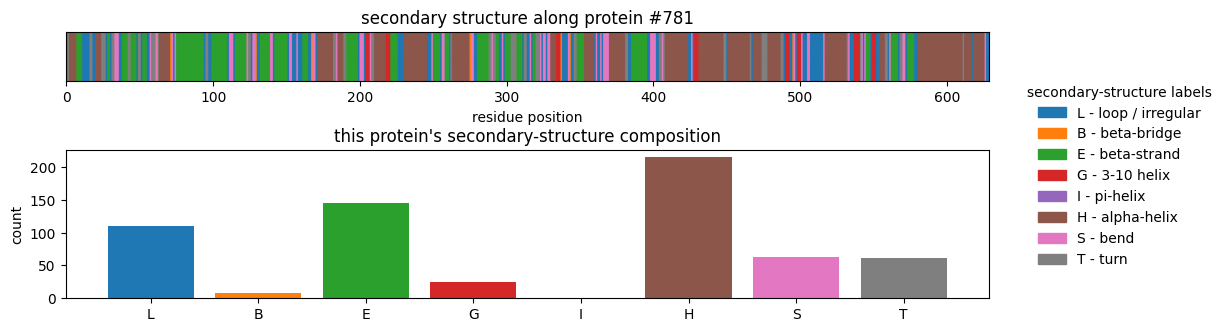

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Full names of the 8 secondary-structure classes (there are 8, plus a 9th
# "NoSeq" padding token -- not 10; the colormap just happens to have 10 colors).
ss_names = {'L':'loop / irregular', 'B':'beta-bridge', 'E':'beta-strand',
            'G':'3-10 helix', 'I':'pi-helix', 'H':'alpha-helix',
            'S':'bend', 'T':'turn', 'NoSeq':'padding'}

# --- pick a random protein (re-run this cell to see a new one) ---
idx = np.random.randint(len(aminos))

aa_i = aminos[idx].argmax(0).numpy()        # amino-acid index at each position
ss_i = labels[idx].argmax(0).numpy()        # secondary-structure index at each position
L = int((aa_i != alphabet.index('NoSeq')).sum())   # real length (drop NoSeq padding)

seq = "".join(alphabet[i]         for i in aa_i[:L])
sst = "".join(secondary_labels[i] for i in ss_i[:L])

print(f"Protein #{idx}   (length {L} residues)\n")
for s in range(0, L, 60):
    print("seq ", seq[s:s+60])
    print("ss  ", sst[s:s+60])
    print()

# consistent colors across the strip, the bar, and the legend
colors = plt.cm.tab10(np.arange(len(secondary_labels)))   # one color per SS class

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 3.6),
                               gridspec_kw={'height_ratios': [1, 3]})
# colored strip: secondary structure along the chain
ax1.imshow(ss_i[:L][None, :], aspect='auto',
           cmap=ListedColormap(colors), vmin=0, vmax=len(secondary_labels) - 1)
ax1.set_yticks([]); ax1.set_xlabel("residue position")
ax1.set_title(f"secondary structure along protein #{idx}")

# bar: this protein's composition (8 real classes, drop NoSeq)
counts = np.bincount(ss_i[:L], minlength=len(secondary_labels))[:8]
ax2.bar(secondary_labels[:8], counts, color=colors[:8])
ax2.set_ylabel("count"); ax2.set_title("this protein's secondary-structure composition")

# legend mapping each label letter -> color + full name (the 8 real classes)
handles = [mpatches.Patch(color=colors[k], label=f"{secondary_labels[k]} - {ss_names[secondary_labels[k]]}")
           for k in range(8)]
# reserve space on the right so the legend sits INSIDE the figure (won't get clipped)
fig.subplots_adjust(left=0.07, right=0.78, top=0.90, bottom=0.16, hspace=0.7)
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(0.80, 0.5),
           title="secondary-structure labels", frameon=False)
plt.show()

In [ ]:
def train_with_data(x, y,
                    model, batch_size, 
                    steps, learning_rate, 
                    loss_function, checkin=100):
  dev = 'cpu'
  if torch.cuda.is_available():
    dev = 'cuda:0'

  model.to(dev)
  model.train()   # training mode: BatchNorm uses batch stats, Dropout is active
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  for step in range(steps):
    batch_i = torch.randint(0, len(x), (batch_size,))
    batch_x = x[batch_i].to(dev)
    batch_y = y[batch_i].to(dev)

    out = model(batch_x)

    loss = loss_function(out, batch_y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if step % checkin == 0:
      print('progress: {:.2%} '.format(step / steps), 'loss:', loss.item())

  model.to('cpu')

# This function tests our accuracy.
# For each real residue (NoSeq padding ignored), the model's "call" is the class
# with the largest output (argmax). It's correct if that call matches the true
# label.
# accuracy = (# residues where the call is the correct class) / (# residues)
def test_accuracy(x, y, model, batch_size=32):
  dev = 'cpu'
  if torch.cuda.is_available():
    dev = 'cuda:0'

  model.to(dev)
  model.eval()   # eval mode: BatchNorm uses running stats, Dropout is off

  correct = 0
  total = 0
  with torch.no_grad():
    batches = int(len(x) / batch_size) - 1  # we lose a little bit of data but that's ok

    for batch in range(batches):
      start_idx = batch * batch_size

      batch_x = x[start_idx:start_idx+batch_size].to(dev)
      batch_y = y[start_idx:start_idx+batch_size].to(dev)

      out = model(batch_x)

      call = torch.argmax(out, dim=1)           # the model's pick at each residue
      true = torch.argmax(batch_y, dim=1)       # the correct class at each residue

      real = batch_y[:, -1, :] == 0             # ignore NoSeq padding positions
      correct += torch.sum((call == true) & real)
      total   += torch.sum(real)

  model.to('cpu')
  return float(correct / total)


#### Build, train, and test a powerful model

This version skips the toy models and goes straight to something that reaches
~0.70 per-residue accuracy. Two ingredients do the heavy lifting:

**1. Evolutionary profile features.** Instead of feeding only the raw amino acid
at each position (22 channels), we feed **44 channels**: the amino-acid one-hot
*plus* the PSSM sequence profile from the dataset (built as `features` in the
setup cell). The profile says which residues evolution tolerates at each
position across related proteins — far more informative than the single observed
amino acid, and the single biggest reason this model beats the simple ones.

**2. A deeper, normalized network.** A stack of wider `Conv1d` layers with:
- **`BatchNorm1d`** after each conv — normalizes activations so training is much
  faster and more stable, which lets us use a 10x larger learning rate.
- **`ELU`** nonlinearities and a mix of kernel sizes (5/7) for a wide receptive
  field that spans whole helices and strands.
- **`Dropout`** before the final layer to curb overfitting.

**Accuracy** is the same per-residue argmax metric as before (padding ignored).
**Loss** is the same `CrossEntropyLoss(ignore_index=8)` on raw logits (no
`Sigmoid`). Note `train_with_data` / `test_accuracy` now call `model.train()` /
`model.eval()` so BatchNorm and Dropout behave correctly in each phase.

This is heavy for a CPU — **switch the Colab runtime to a GPU** (Runtime → Change
runtime type → T4) and it trains in well under a minute.

In [ ]:
batch_size = 64 # How many proteins we train on at every step
steps = 4000 # How many total steps we will train for
learning_rate = 0.001 # BatchNorm lets us train ~10x faster than the toy models
checkin = int(steps / 10) # How often we print our loss (smaller = more frequently)

# CrossEntropyLoss is the natural loss for "pick one class per residue". It
# applies softmax internally, so the model outputs raw scores (logits) -- there
# is no Sigmoid on the end. `ignore_index=8` drops the NoSeq padding positions
# from the loss. Our labels are stored one-hot, so this wrapper converts them to
# class indices on the fly.
cross_entropy = nn.CrossEntropyLoss(ignore_index=8)  # 8 = NoSeq padding
def loss_function(out, target_onehot):
    return cross_entropy(out, torch.argmax(target_onehot, dim=1))


# A much stronger model:
#  - input is 44 channels (amino-acid one-hot + PSSM evolutionary profile)
#  - deeper/wider conv stack with BatchNorm for fast, stable training
#  - mixed kernel sizes (5/7) for a wide receptive field
#  - Dropout before the final layer to curb overfitting
model = nn.Sequential(
    nn.Conv1d(44, 64, kernel_size=5, stride=1, padding='same'), nn.BatchNorm1d(64), nn.ELU(),
    nn.Conv1d(64, 64, kernel_size=7, stride=1, padding='same'), nn.BatchNorm1d(64), nn.ELU(),
    nn.Conv1d(64, 64, kernel_size=7, stride=1, padding='same'), nn.BatchNorm1d(64), nn.ELU(),
    nn.Dropout(0.3),
    nn.Conv1d(64, 9, kernel_size=5, stride=1, padding='same'))

print("Accuracy: ", round(test_accuracy(features_test, labels_test, model), 3))



train_with_data(features_train, labels_train, model, 
                batch_size, steps, learning_rate, 
                loss_function, checkin=checkin)


print("Accuracy: ", round(test_accuracy(features_test, labels_test, model), 3))